Inspired by https://pmc.ncbi.nlm.nih.gov/articles/PMC9862022/
we seek to assemble a dataset of breast cancer with available survival data and RNAseq data.

from https://portal.gdc.cancer.gov/ we gather 1094 cases with

* primary site = breast
* vital status = dead, alive
* data type = Gene expression Quantification
* platform = illumina
* project = TGCA-BRCA

Then we will load these cases clinical data and select the ones for which we have actionable survival data

## data first contact  + filtering

for our purpose we want to ids of the samples with a known age and which can be categorized as having survived >5years or not (ie. dead or follow-up > 5years).

In [24]:
import pandas as pd

df = pd.read_table( "clinical.tsv", na_values = ["'--"] )
nrow_before = df.shape[0]
df.drop_duplicates(inplace=True, ignore_index = True, subset = ['cases.case_id'])
print(f"de-duplication: {nrow_before} -> {df.shape[0]} rows")
df.head()

de-duplication: 5528 -> 1094 rows


/tmp/ipykernel_4005939/3065757153.py:3: DtypeWarning: Columns (0: demographic.age_is_obfuscated, 1: diagnoses.diagnosis_is_primary_disease, 2: diagnoses.figo_stage, 3: diagnoses.last_known_disease_status, 4: diagnoses.progression_or_recurrence, 5: diagnoses.tumor_grade, 6: treatments.regimen_or_line_of_therapy) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table( "clinical.tsv", na_values = ["'--"] )


,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type,treatments.treatment_type_administered
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34.0,NaN,Ductal and Lobular Neoplasms,Diagnosis,NaN,Breast,TCGA-E2-A1IU,...,NaN,NaN,NaN,1b884f21-eb24-467f-aba2-208af17070b9,Adjuvant,no,NaN,NaN,"Radiation Therapy, NOS",NaN
1,TCGA-BRCA,0045349c-69d9-4306-a403-c9c1fa836644,Informed Consent,76.0,NaN,Adenomas and Adenocarcinomas,Diagnosis,NaN,Breast,TCGA-A1-A0SB,...,NaN,NaN,NaN,0a534cae-de91-5e77-a3e7-b52d46bd3966,First-Line Therapy,yes,NaN,NaN,"Surgery, NOS",NaN
2,TCGA-BRCA,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Informed Consent,19.0,NaN,Adnexal and Skin Appendage Neoplasms,Diagnosis,No,Breast,TCGA-A2-A04W,...,NaN,NaN,NaN,024faa94-ec57-4d14-b919-62dcab409958,Adjuvant,yes,Treatment Ongoing,NaN,Bisphosphonate Therapy,NaN
3,TCGA-BRCA,00a2d166-78c9-4687-a195-3d6315c27574,Informed Consent,0.0,NaN,Ductal and Lobular Neoplasms,Diagnosis,Yes,Breast,TCGA-AN-A0AM,...,NaN,NaN,NaN,42bf7d51-03ef-49df-b369-979bdbf3efb3,First-Line Therapy,yes,NaN,NaN,"Surgery, NOS",NaN
4,TCGA-BRCA,00b11ca8-8540-4a3d-b602-ec754b00230b,Informed Consent,11.0,NaN,Ductal and Lobular Neoplasms,Diagnosis,No,Breast,TCGA-LL-A440,...,NaN,NaN,NaN,977027ad-66fd-4273-b0d4-f14696c25c1a,NaN,no,NaN,NaN,"Pharmaceutical Therapy, NOS",NaN


In [25]:
df['cases.lost_to_followup'].value_counts()

cases.lost_to_followup
No     549
Yes     64
Name: count, dtype: int64

In [29]:
## all NAs
df['cases.days_to_lost_to_followup'].isna().sum()

np.int64(1094)

In [30]:
df['demographic.vital_status'].value_counts()

demographic.vital_status
Alive    942
Dead     152
Name: count, dtype: int64

<Axes: xlabel='demographic.days_to_birth', ylabel='demographic.days_to_death'>

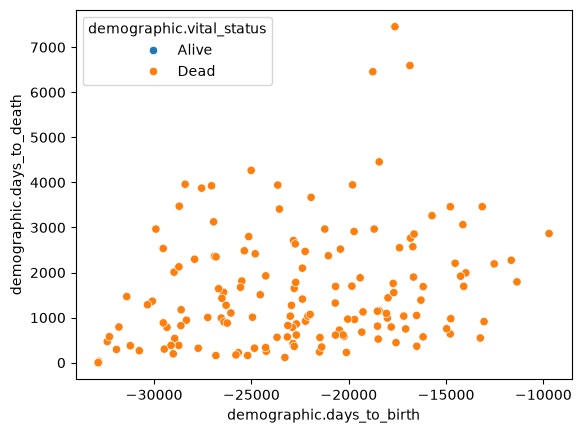

In [31]:
import seaborn as sns

sns.scatterplot( df , x = "demographic.days_to_birth" , 
               y = "demographic.days_to_death",
                hue = 'demographic.vital_status')

<Axes: xlabel='demographic.days_to_birth', ylabel='None'>

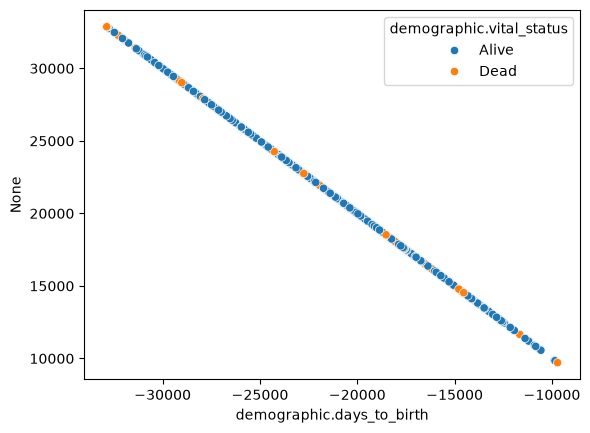

In [36]:
import seaborn as sns

sns.scatterplot( df , x = "demographic.days_to_birth" , 
               y = df['diagnoses.age_at_diagnosis']-df['diagnoses.days_to_diagnosis'],
                hue = 'demographic.vital_status')


/tmp/ipykernel_4005939/3802054141.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['demographics.days_to_last_follow_up'] = df['diagnoses.days_to_last_follow_up'] + df['diagnoses.days_to_diagnosis']


<Axes: xlabel='demographic.days_to_birth', ylabel='demographics.days_to_last_follow_up'>

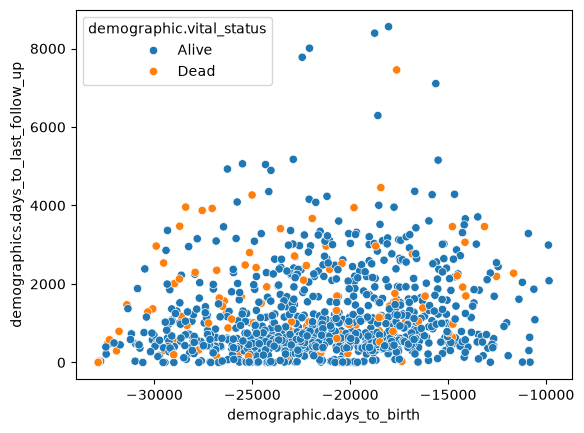

In [37]:
## index age to last follow up
df['demographics.days_to_last_follow_up'] = df['diagnoses.days_to_last_follow_up'] + df['diagnoses.days_to_diagnosis']
sns.scatterplot( df , x = "demographic.days_to_birth" , 
               y = "demographics.days_to_last_follow_up",
                hue = 'demographic.vital_status')


We can integrate if valid "demographic.days_to_birth" and one of:
 * dead and "demographic.days_to_death" is not na
 * alive and "demographics.days_to_last_follow_up" > 5 years

In [40]:
threshold = 365.25*5 # 5 years

mask_days_to_birth = ~df["demographic.days_to_birth"].isna()
mask_dead = ( df['demographic.vital_status'] == "Dead" ) & ( ~df["demographic.days_to_death"].isna() ) 
mask_alive = ( df['demographic.vital_status'] == "Alive" ) & ( df["demographics.days_to_last_follow_up"]>threshold ) 

mask_combined = mask_days_to_birth & (mask_dead|mask_alive)
mask_combined.value_counts()

False    762
True     332
Name: count, dtype: int64

In [43]:
df = df.loc[ mask_combined , : ]


df["poor_prognosis"] =  df['demographic.days_to_death'] <= threshold  # survived < 5years
df["poor_prognosis"].value_counts()

/tmp/ipykernel_4005939/1968782252.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["poor_prognosis"] =  df['demographic.days_to_death'] <= threshold  # survived < 5years


poor_prognosis
False    231
True     101
Name: count, dtype: int64

In [44]:
df.to_csv( "clinical_filtered_annotated.csv" )

Index(['project.project_id', 'cases.case_id', 'cases.consent_type',
       'cases.days_to_consent', 'cases.days_to_lost_to_followup',
       'cases.disease_type', 'cases.index_date', 'cases.lost_to_followup',
       'cases.primary_site', 'cases.submitter_id',
       ...
       'treatments.treatment_frequency', 'treatments.treatment_id',
       'treatments.treatment_intent_type', 'treatments.treatment_or_therapy',
       'treatments.treatment_outcome', 'treatments.treatment_outcome_duration',
       'treatments.treatment_type', 'treatments.treatment_type_administered',
       'demographics.days_to_last_follow_up', 'poor_prognosis'],
      dtype='str', length=204)

In [101]:
df[['cases.case_id',"poor_prognosis","demographic.days_to_birth",'demographic.sex_at_birth']].to_csv("clinical_filtered.small.csv",index = False)


## looking at transcriptomic data

we return to https://portal.gdc.cancer.gov/ and gather the count tables for the 332 selected samples.

We select:
 
 * Platform = illumina
 * Tissue Type = tumor
 * Tumor Descriptor = primary
 * Data format = tsv
 * Data type  = Gene Expression Quantification


In [50]:
import json
with open('TGCA_BRCA_expression_data/metadata.cart.2026-07-22.json') as IN:
    download_metadata = json.load(IN)

In [61]:
case_to_xpr_file = {}
for rec in download_metadata:

    caseID = rec['associated_entities'][0]['case_id']
    filename = f'TGCA_BRCA_expression_data/{rec['file_id']}/{rec['file_name']}'
    
    if caseID in case_to_xpr_file:
        print(f'doublon for {caseID}')
        print('\t',case_to_xpr_file[caseID])
        print('\t',filename)
    
    case_to_xpr_file[caseID] = filename
#( df['cases.case_id'] == caseID ).sum()

doublon for 8c7e74e0-71ef-49b8-9217-94b8ef740ef9
	 TGCA_BRCA_expression_data/0a511373-8fd3-433a-a5e1-877530d6a239/5991af25-0b64-43d2-867a-6b9713b17af9.rna_seq.augmented_star_gene_counts.tsv
	 TGCA_BRCA_expression_data/06952c59-978d-4ef4-b716-c55dd6747699/e843a939-f1a2-4e98-87b5-69abef893a51.rna_seq.augmented_star_gene_counts.tsv
doublon for 8c7e74e0-71ef-49b8-9217-94b8ef740ef9
	 TGCA_BRCA_expression_data/06952c59-978d-4ef4-b716-c55dd6747699/e843a939-f1a2-4e98-87b5-69abef893a51.rna_seq.augmented_star_gene_counts.tsv
	 TGCA_BRCA_expression_data/4b96ee43-874c-4fa6-b5ce-08caf37ef2e1/d27304e0-1b0b-4fc3-8e0d-af2c305d30f8.rna_seq.augmented_star_gene_counts.tsv


I checked: these seem to simply be replicates. I'll ignore 

In [65]:
def infer_stranding( xpr_table ):
    first = xpr_table.loc[0,'stranded_first']
    second = xpr_table.loc[0,'stranded_second']
    if first > 2*second:
        return 'stranded_first'
    elif first*2 < second:
        return 'stranded_second'
    return 'unstranded'

for case, filename in case_to_xpr_file.items():
    xpr = pd.read_table(filename , skiprows= 1)
    strand = infer_stranding( xpr )
    if strand != "unstranded":
        print(case,strand)

all cases are presumably unstranded!!

In [79]:
case_to_xpr_table = {}
for case, filename in case_to_xpr_file.items():
    xpr = pd.read_table(filename , skiprows= 1)
    case_to_xpr_table[case] = xpr[ [ 'gene_id' , 'gene_name','gene_type' , 'tpm_unstranded' ] ]

In [80]:
ref = list( case_to_xpr_table.values()  )[0].gene_id
ref
for case, xpr in case_to_xpr_table.items():
    if (ref == xpr.gene_id).mean() != 1.0:
        print("differing gene_id:",case)

all the same annotation

In [92]:
df_xpr = pd.DataFrame({ case: list( xpr["tpm_unstranded"]) for case, xpr in case_to_xpr_table.items() })

In [93]:
ref_table = list( case_to_xpr_table.values()  )[0]
df_xpr['gene_name'] = ref_table.gene_name
df_xpr['gene_type'] = ref_table.gene_type
df_xpr.index= ref_table.gene_id


In [94]:
df_xpr.drop( index = ['N_unmapped','N_multimapping','N_noFeature','N_ambiguous'],inplace=True )
df_xpr.head()

,d0b78f3f-a198-437a-ab8c-204345d3b75d,28e9048a-e540-42de-a1f4-4ef894fccc4c,1dafdd64-527d-4d46-bbdf-7a97774f881b,1402082d-25c9-4148-8a1e-f58450b706bb,5a4b7098-1f6a-49e9-b364-29d6d34f5bd5,b094e8b2-8ece-4b36-8025-18073a8b873c,aa30ac3d-4216-45dd-a314-1ae192fafcb2,4a032bad-e726-48f2-8f39-e3acc109cc91,e663954c-05a8-479a-a623-400c1eb5efc6,8a0ef221-8070-43fc-9d98-def90abe4871,...,70931617-b3df-4a12-8e3f-2b2307602f48,71f97b63-c970-44ee-98c2-e02e663d5a40,71626753-cc34-4731-abc0-ae188b0964e7,9964f447-92ad-4d1e-af20-11cf84fab7b0,6a2972e3-cca9-47e5-aac0-b770f2399eeb,6b960b58-28e1-41c6-bd6e-7e669c6aa4ef,1133b8a9-6b11-4511-b70a-f200e3b8b5db,65cac997-4d39-4501-85ec-4fcb328a8eb5,gene_name,gene_type
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,12.0296,38.9397,48.2142,113.1190,38.3992,35.8583,15.8171,12.2836,96.2927,38.2183,...,64.2974,46.5228,46.3566,21.4357,23.1162,16.2476,14.1016,19.3988,TSPAN6,protein_coding
ENSG00000000005.6,0.3785,12.4455,2.7540,0.4400,3.6813,1.2633,0.1749,0.4024,0.3354,7.9302,...,0.1178,3.0742,0.0946,0.1388,2.8497,1.0984,0.5293,0.1661,TNMD,protein_coding
ENSG00000000419.13,134.9047,150.4751,108.2244,82.5384,82.5875,126.3276,110.1601,269.9088,110.2489,130.7081,...,90.0998,151.7356,88.6381,91.9256,251.4485,199.1859,61.2477,178.5804,DPM1,protein_coding
ENSG00000000457.14,15.5758,9.6899,12.9741,19.6494,12.3135,11.6259,30.9337,16.7549,14.6498,17.2712,...,13.3749,13.0032,19.9034,11.2773,17.6783,13.9854,18.7566,7.4212,SCYL3,protein_coding
ENSG00000000460.17,4.3777,9.2941,5.0428,8.9295,5.7586,17.3216,10.2454,9.6406,5.6393,5.2305,...,8.3727,12.2600,3.0277,3.5764,15.7687,22.2571,3.6969,12.0377,C1orf112,protein_coding


In [95]:
df_xpr.to_csv("expression_matrix.TPM.csv")

## preliminary analysis

In [97]:
df_xpr = pd.read_csv("expression_matrix.TPM.csv.gz" , index_col = 0)
df_xpr.head()

,d0b78f3f-a198-437a-ab8c-204345d3b75d,28e9048a-e540-42de-a1f4-4ef894fccc4c,1dafdd64-527d-4d46-bbdf-7a97774f881b,1402082d-25c9-4148-8a1e-f58450b706bb,5a4b7098-1f6a-49e9-b364-29d6d34f5bd5,b094e8b2-8ece-4b36-8025-18073a8b873c,aa30ac3d-4216-45dd-a314-1ae192fafcb2,4a032bad-e726-48f2-8f39-e3acc109cc91,e663954c-05a8-479a-a623-400c1eb5efc6,8a0ef221-8070-43fc-9d98-def90abe4871,...,70931617-b3df-4a12-8e3f-2b2307602f48,71f97b63-c970-44ee-98c2-e02e663d5a40,71626753-cc34-4731-abc0-ae188b0964e7,9964f447-92ad-4d1e-af20-11cf84fab7b0,6a2972e3-cca9-47e5-aac0-b770f2399eeb,6b960b58-28e1-41c6-bd6e-7e669c6aa4ef,1133b8a9-6b11-4511-b70a-f200e3b8b5db,65cac997-4d39-4501-85ec-4fcb328a8eb5,gene_name,gene_type
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.15,12.0296,38.9397,48.2142,113.1190,38.3992,35.8583,15.8171,12.2836,96.2927,38.2183,...,64.2974,46.5228,46.3566,21.4357,23.1162,16.2476,14.1016,19.3988,TSPAN6,protein_coding
ENSG00000000005.6,0.3785,12.4455,2.7540,0.4400,3.6813,1.2633,0.1749,0.4024,0.3354,7.9302,...,0.1178,3.0742,0.0946,0.1388,2.8497,1.0984,0.5293,0.1661,TNMD,protein_coding
ENSG00000000419.13,134.9047,150.4751,108.2244,82.5384,82.5875,126.3276,110.1601,269.9088,110.2489,130.7081,...,90.0998,151.7356,88.6381,91.9256,251.4485,199.1859,61.2477,178.5804,DPM1,protein_coding
ENSG00000000457.14,15.5758,9.6899,12.9741,19.6494,12.3135,11.6259,30.9337,16.7549,14.6498,17.2712,...,13.3749,13.0032,19.9034,11.2773,17.6783,13.9854,18.7566,7.4212,SCYL3,protein_coding
ENSG00000000460.17,4.3777,9.2941,5.0428,8.9295,5.7586,17.3216,10.2454,9.6406,5.6393,5.2305,...,8.3727,12.2600,3.0277,3.5764,15.7687,22.2571,3.6969,12.0377,C1orf112,protein_coding


In [102]:
df_clinical = pd.read_csv("clinical_filtered.small.csv",index_col=0)
df_clinical.head()

,poor_prognosis,demographic.days_to_birth,demographic.sex_at_birth
cases.case_id,,,
00807dae-9f4a-4fd1-aac2-82eb11bf2afb,False,-18345.0,female
016caf42-4e19-4444-ab5d-6cf1e76c4afa,False,-22340.0,female
01eef340-598c-4205-a990-cec190ac2ca5,False,-14669.0,female
035cb359-eac3-484a-9e88-3ddc739440a3,False,-22833.0,female
045c13ef-3db7-4adf-b0a3-23338f0479f3,True,-18014.0,female


In [103]:
y = df_clinical.poor_prognosis
X_xpr = df_xpr.loc[ :, df_clinical.index].transpose() 
X_xpr.shape

(332, 60660)

In [180]:
y.value_counts()

poor_prognosis
False    231
True     101
Name: count, dtype: int64

In [113]:
## how long to train a single model with so many features?
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

Xs = StandardScaler().fit_transform(X_xpr)

lr = LogisticRegression( max_iter = 1000)
%time lr.fit(  Xs , y )


CPU times: user 7.95 s, sys: 0 ns, total: 7.95 s
Wall time: 1.09 s


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [111]:
## how many of these have a coefficient ?
( lr.coef_ != 0  ).sum()

np.int64(56963)

In [117]:
from sklearn.metrics import accuracy_score

## very likely overfit model
accuracy_score(y , lr.predict( Xs ))

1.0

In [132]:
# https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html#sklearn.feature_selection.mutual_info_classif
#from sklearn.feature_selection import mutual_info_classif

## takes very long
#MI = mutual_info_classif(X_xpr , y)

In [155]:
from sklearn.feature_selection import chi2

%time CHI2 = pd.Series( chi2(X_xpr , y)[1] , index = X_xpr.columns )# get the pvalues

CPU times: user 839 ms, sys: 518 µs, total: 839 ms
Wall time: 268 ms


/tmp/ipykernel_4005939/987069688.py:2: RuntimeWarning: divide by zero encountered in log10
  sns.histplot(np.log10(CHI2))


<Axes: ylabel='Count'>

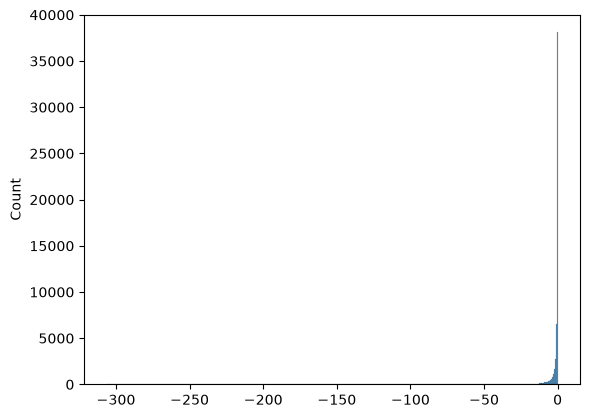

In [142]:
import numpy as np
sns.histplot(np.log10(CHI2))

In [150]:
X_xpr.var()[ np.log10(CHI2) < -50 ]

/tmp/ipykernel_4005939/1363892835.py:1: RuntimeWarning: divide by zero encountered in log10
  X_xpr.var()[ np.log10(CHI2) < -50 ]


gene_id
ENSG00000002726.21      238.261421
ENSG00000002834.18    54982.731120
ENSG00000003989.18    36062.267774
ENSG00000004478.8     21563.152305
ENSG00000004799.8      6580.903793
                          ...     
ENSG00000286522.2      2011.590500
ENSG00000287064.1       516.102057
ENSG00000287262.1       568.953685
ENSG00000287535.1       876.622621
ENSG00000287861.1      2993.733260
Length: 883, dtype: float64

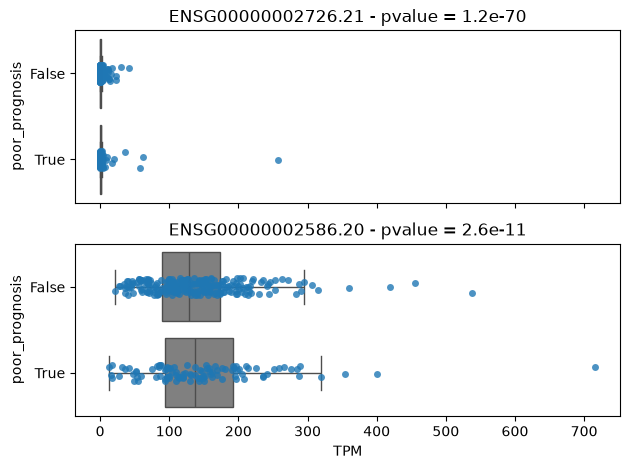

In [160]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(2,1, sharex=True)
for i, gene in enumerate(['ENSG00000002726.21' , 'ENSG00000002586.20']):
    
    sns.stripplot( x = X_xpr[gene] , y=y , orient='horizontal' , ax=ax[i],  alpha = 0.8)
    sns.boxplot( x = X_xpr[gene] , y=y , orient='horizontal' , ax=ax[i] , fliersize= 0 , color ='grey')
    ax[i].set_xlabel("TPM")
    ax[i].set_title(f'{gene} - pvalue = {CHI2[gene]:.1e}')

fig.tight_layout()

Text(0.5, 1.0, 'fraction of genes with 0 variance: 0.061')

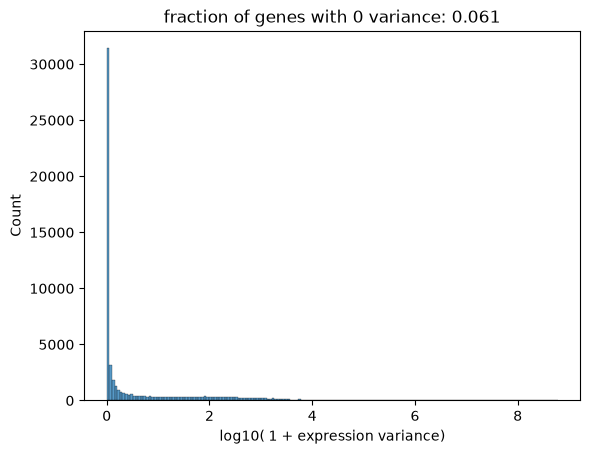

In [170]:
sns.histplot(np.log10(1+X_xpr.var()) )
plt.xlabel("log10( 1 + expression variance)")
plt.title(f"fraction of genes with 0 variance: {(X_xpr.var()==0).mean():.3f}")

In [175]:
threshold = X_xpr.var().quantile(0.9)
top10_percent = X_xpr.var() > threshold

Text(0, 0.5, 'log( 1 + mean variance )')

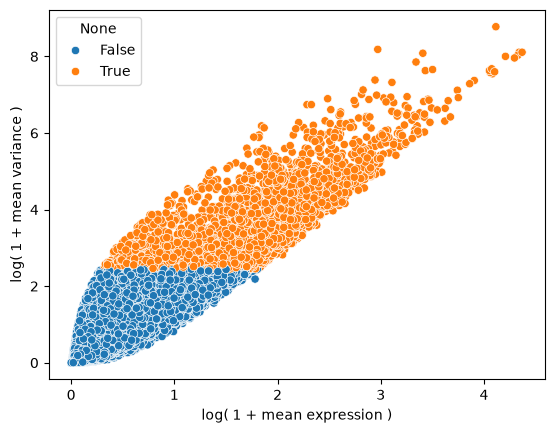

In [177]:

sns.scatterplot( x = np.log10(1+X_xpr.mean()) , y= np.log10(1+X_xpr.var()) , hue = top10_percent )
plt.xlabel('log( 1 + mean expression )')
plt.ylabel('log( 1 + mean variance )')

In [228]:
from sklearn.feature_selection import VarianceThreshold

threshold = X_xpr.var(ddof = 0).quantile(0.9)

VT = VarianceThreshold(threshold)
X_filtered = VT.fit_transform(X_xpr)
X_filtered.shape

(332, 6066)

In [229]:
## alternative with SelectPercentile
## a bit more adavcned because you need a lambda function
## but as you do not have to compute the threshold beforehand you can fit this more easily into pipeline and 
## proper cross-validation loops

from sklearn.feature_selection import SelectPercentile


VT = SelectPercentile( score_func = lambda x,_ : np.var(x , axis = 0) ,
                       percentile = 10
                     )
X_filtered = VT.fit_transform(X_xpr)
X_filtered.shape

(332, 6066)

In [232]:
X_filtered = pd.DataFrame( X_filtered , 
                          columns= VT.get_feature_names_out() , 
                          index = X_xpr.index)
X_filtered.head()

,ENSG00000000003.15,ENSG00000000419.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001167.14,ENSG00000001561.7,ENSG00000001617.12,ENSG00000001629.10,ENSG00000002549.12,ENSG00000002586.20,...,ENSG00000286451.1,ENSG00000286522.2,ENSG00000287064.1,ENSG00000287262.1,ENSG00000287448.1,ENSG00000287535.1,ENSG00000287826.1,ENSG00000287853.1,ENSG00000287861.1,ENSG00000287914.1
cases.case_id,,,,,,,,,,,,,,,,,,,,,
00807dae-9f4a-4fd1-aac2-82eb11bf2afb,39.1028,103.4823,8.6111,51.4060,21.7640,5.1852,76.2241,20.6486,43.2062,359.7767,...,22.0800,1.2771,0.0533,10.1198,0.0000,0.1637,0.0000,0.9581,0.0000,0.0000
016caf42-4e19-4444-ab5d-6cf1e76c4afa,19.8399,132.1468,23.9956,45.3165,44.2389,10.1732,47.6155,72.4895,678.3737,83.6738,...,3.1887,0.8182,0.0854,0.6952,0.2406,0.6225,0.1183,61.1703,0.0000,0.4998
01eef340-598c-4205-a990-cec190ac2ca5,82.0382,105.8248,3.2903,49.0391,101.2453,4.5987,25.2149,27.2396,50.5011,28.1757,...,19.0259,1.1188,0.1334,0.6519,0.0000,0.9473,0.0000,0.2665,0.0540,0.0558
035cb359-eac3-484a-9e88-3ddc739440a3,13.8296,87.8090,29.7580,67.4281,60.4574,7.1575,61.3899,21.7442,81.2123,243.8535,...,13.5832,5.0499,0.3514,39.0456,8.6560,0.3467,0.2225,2.0046,0.0000,50.7810
045c13ef-3db7-4adf-b0a3-23338f0479f3,45.6304,140.8339,17.4644,67.6851,27.1013,8.9638,28.2951,36.1881,102.3497,136.7956,...,18.4928,2.1054,0.2705,1.4155,0.0000,0.3632,0.0749,3.5777,0.1095,0.1131


In [233]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

lr_ppl = Pipeline( [('scale',StandardScaler()),
                    ('model',LogisticRegression())] )

%time cross_val_score(lr_ppl , X_filtered , y , cv = 5 , scoring = 'accuracy')

CPU times: user 8.62 s, sys: 14.5 ms, total: 8.63 s
Wall time: 1.21 s


array([0.70149254, 0.70149254, 0.66666667, 0.72727273, 0.66666667])

## exercise

---

1. use different thresholds for variance selection, and evaluate them with `cross_val_score`. 

      * the top 50% variables genes
      * the top 0.1% variable genes
     
    Which one yields the better cross-validated accuracy?
     
--- 
     
2. select the top 10% variable genes, then use [SelectKbest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html#sklearn.feature_selection.SelectKBest) (use `chi2` as scoring function) to get the top 500 genes. 
    Which cross-validated accuracy fo you get?


In [237]:
%%time
threshold = [50,10,0.1]
lr_ppl = Pipeline( [('scale',StandardScaler()),
                    ('model',LogisticRegression())] )


for t in threshold:
    
    VT = SelectPercentile( score_func = lambda x,_ : np.var(x , axis = 0) ,
                       percentile = t
                     )
    
    X_filtered = VT.fit_transform(X_xpr)
    
    cross_val_acc = cross_val_score(lr_ppl , X_filtered , y , cv = 5 , scoring = 'accuracy').mean()
    print(f'top {t}% : cross-validated accuracy: {cross_val_acc:.2f}')
    


top 50% : cross-validated accuracy: 0.64
top 10% : cross-validated accuracy: 0.69
top 0.1% : cross-validated accuracy: 0.65
CPU times: user 36.9 s, sys: 4.2 s, total: 41.1 s
Wall time: 10.1 s


In [245]:
%%time
from sklearn.feature_selection import SelectKBest , chi2

VT = SelectPercentile( score_func = lambda x,_ : np.var(x , axis = 0) ,
                       percentile = 10
                     )
SKB = SelectKBest(score_func=chi2 , k = 500 )

X_filtered1 = VT.fit_transform(X_xpr)
X_filtered2 = SKB.fit_transform( X_filtered1 , y )


cross_val_acc = cross_val_score(lr_ppl , X_filtered2 , y , cv = 5 , scoring = 'accuracy').mean()

print(f'top 10% variant -> top 500 (chi2 stats): cross-validated accuracy: {cross_val_acc:.2f}')

top 10% variant -> top 500 (chi2 stats): cross-validated accuracy: 0.73
CPU times: user 1.09 s, sys: 307 ms, total: 1.4 s
Wall time: 803 ms
